/tmp/ipykernel_3231/1198230903.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Y[i]=np.exp(2*X[i])


0 8.89 ('lr=', 0.01)
1000 0.09 ('lr=', 0.25)
2000 0.06 ('lr=', 0.25)
3000 0.05 ('lr=', 0.25)
4000 0.04 ('lr=', 0.25)
5000 0.04 ('lr=', 0.25)
6000 0.03 ('lr=', 0.25)
7000 0.03 ('lr=', 0.25)
8000 0.03 ('lr=', 0.25)
9000 0.02 ('lr=', 0.25)
10000 0.02 ('lr=', 0.25)
11000 0.02 ('lr=', 0.25)
12000 0.02 ('lr=', 0.25)
13000 0.02 ('lr=', 0.25)
14000 0.02 ('lr=', 0.25)
15000 0.02 ('lr=', 0.25)
16000 0.02 ('lr=', 0.25)
17000 0.02 ('lr=', 0.25)
18000 0.02 ('lr=', 0.25)
19000 0.01 ('lr=', 0.25)


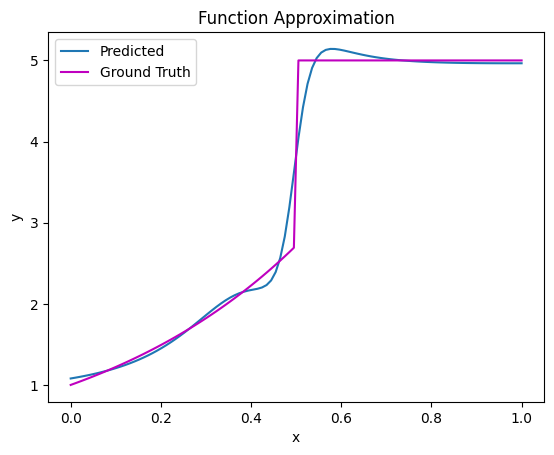

In [1]:
import torch as t
import matplotlib.pyplot as plt
import numpy as np
import pdb
#pdb.set_trace()

#https://medium.com/@shashankshankar10/introduction-to-neural-networks-build-a-single-layer-perceptron-in-pytorch-c22d9b412ccf
#https://phuijse.github.io/MachineLearningBook/contents/neural_networks/torch-training.html

X = t.linspace(0, 1, 100)
X=t.reshape(X,(X.size(dim=0),1))  #pytorch seems to work with column tensors

Y = t.zeros(X.shape[0],1)
for i in range(X.size(dim=0)):
  if X[i]<=0.5:
    Y[i]=np.exp(2*X[i])
  else:
    Y[i]=5.0


#plt.plot(X, Y)
#plt.xlabel('X')
#plt.ylabel('Y')
#plt.show()

class NNet(t.nn.Module):
    def __init__(self, input_size, hidden_neurons, output_size):
        super(NNet, self).__init__()
        # Define the first hidden layer with input_size input features and hidden_neurons neurons
        self.hidden_layer1 = t.nn.Linear(input_size, hidden_neurons)
        # Define the second hidden layer with input_size input features and hidden_neurons neurons
        self.hidden_layer2 = t.nn.Linear(hidden_neurons, hidden_neurons)
        # Define the output layer with hidden_neurons input features and output_size neurons
        self.output_layer = t.nn.Linear(hidden_neurons, output_size)

#Define a Prediction Function
    def forward(self, x):
        # Pass the input through the first hidden layer and apply the sigmoid activation function
        hidden_output1 = t.sigmoid(self.hidden_layer1(x))
        # Pass  through the 2nd hidden layer and apply the sigmoid activation function
        hidden_output2 = t.sigmoid(self.hidden_layer2(hidden_output1))
        # Pass the hidden layer 2 output through the output layer without apply the sigmoid activation function
        y_pred = self.output_layer(hidden_output2)

        return y_pred

#Instantiate a model object :create the model
model = NNet(1, 3, 1)
# 3 represents 3 neurons in each hidden layer
#print(model.hidden_layer1.weight,model.hidden_layer1.bias)
#print(model.hidden_layer2.weight,model.hidden_layer2.bias)


# Define the loss function (criterion)
def criterion(y_pred, y_true):
    loss = y_pred-y_true
    mean_loss = 0.5*t.mean(loss**2)
    return mean_loss

# Assuming 'model' is an instance of your custom neural network
# Create an optimizer (Stochastic Gradient Descent - SGD)
optimizer = t.optim.SGD(model.parameters(), lr=0.01,momentum=0.0, weight_decay=0)
#optimizer = t.optim.RMSprop(model.parameters(), lr=0.01)
scheduler = t.optim.lr_scheduler.ExponentialLR(optimizer, gamma=1)


# Define the training loop
epochs = 20000
cost = []  # List to store the total loss at each epoch
lr_record=[]

for epoch in range(epochs):
    total_loss = 0  # Variable to store the total loss for the current epoch
    yhat = model.forward(X)
    optimizer.zero_grad()
    loss = criterion(yhat, Y)
    loss.backward()
    if epoch % 1000 ==0:
      print(f"{epoch} {loss.item():0.2f} {'lr=',optimizer.param_groups[0]['lr']}")
    if epoch % 500 ==0:
      optimizer.param_groups[0]['lr']=0.25
    optimizer.step()
    scheduler.step()
    cost.append(loss.item())
    lr_record.append(optimizer.param_groups[0]['lr'])




predicted_values = model(X).detach().numpy()
plt.plot(X.numpy(), predicted_values)  # Plot the predicted values
plt.plot(X.numpy(), Y.numpy(), 'm')  # Plot the ground truth data (Y)
plt.xlabel('x')
plt.ylabel('y')
plt.legend(['Predicted', 'Ground Truth'])
plt.title(f'Function Approximation')
plt.show()


#    for x, y in zip(X, Y):
        # Forward pass: Calculate the predicted output (yhat) using the model
#        yhat = model(x)

        # Calculate the loss between the predicted output (yhat) and the actual target (y)
#        loss = criterion(yhat, y)

        # Backpropagation: Compute gradients of the model parameters with respect to the loss
#        loss.backward()

        # Update the model parameters using the computed gradients
#        optimizer.step()

        # Zero out the gradients for the next iteration to avoid accumulation
#        optimizer.zero_grad()

        # Accumulate the loss for this batch of data
#        total_loss += loss.item()

    # Append the total loss for this epoch to the cost list
#    cost.append(total_loss)
#    cost.append(loss.item())
#    if epoch % 1000 == 0:
#        print(f"Epoch {epoch,loss.item()} done!")  # Print status after every 1000 epochs

        # Plot the result of the function approximator
#        predicted_values = model(X).detach().numpy()
#        plt.plot(X.numpy(), predicted_values)  # Plot the predicted values
#        plt.plot(X.numpy(), Y.numpy(), 'm')  # Plot the ground truth data (Y)
#        plt.xlabel('x')
#        plt.ylabel('y')
#        plt.legend(['Predicted', 'Ground Truth'])
#        plt.title(f'Epoch {epoch} - Function Approximation')
#        plt.show()

# Plot the cost (loss) over epochs
#plt.plot(cost, marker='o', linestyle='-', color='b', label='Training Loss')

# Set labels and title
#plt.xlabel('Epochs')
#plt.ylabel('Cross Entropy Loss')
#plt.title('Training Progress - Cross Entropy Loss')

# Add grid for better readability
#plt.grid(True)

# Show legend
#plt.legend()

# Display the plot
#plt.show()

In [ ]:
z=t.tensor([0.5])
z.requires_grad = True
print(z)
w=t.autograd.grad(model(z),z)
print('w',w)
print(model(z))
print(X[0])

tensor([0.5000], requires_grad=True)
w (tensor([18.5416]),)
tensor([3.8113], grad_fn=<ViewBackward0>)
tensor([0.])
